In [1]:
# Import important library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [63]:
# calculate accuracy measures and confusion matrix
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc,roc_curve,roc_auc_score

### Read the input file and check the data dimension

In [4]:
# You can access from https://www.kaggle.com/uciml/german-credit
#Read input file and understand the data
# "default" is my dependent variable

In [5]:
#Read German Credit data from german_credit.csv  file
germanCredit_df = pd.read_csv("german_credit.csv")

In [6]:
germanCredit_df.head()

,default,account_check_status,duration_in_month,credit_history,purpose,credit_amount,savings,present_emp_since,installment_as_income_perc,personal_status_sex,...,present_res_since,property,age,other_installment_plans,housing,credits_this_bank,job,people_under_maintenance,telephone,foreign_worker
0,0,< 0 DM,6,critical account/ other credits existing (not ...,domestic appliances,1169,unknown/ no savings account,.. >= 7 years,4,male : single,...,4,real estate,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes
1,1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,...,2,real estate,22,none,own,1,skilled employee / official,1,none,yes
2,0,no checking account,12,critical account/ other credits existing (not ...,(vacation - does not exist?),2096,... < 100 DM,4 <= ... < 7 years,2,male : single,...,3,real estate,49,none,own,1,unskilled - resident,2,none,yes
3,0,< 0 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,...,4,if not A121 : building society savings agreeme...,45,none,for free,1,skilled employee / official,2,none,yes
4,1,< 0 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,...,4,unknown / no property,53,none,for free,2,skilled employee / official,2,none,yes


In [7]:
#Get German Crdit dataset information
germanCredit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
default                       1000 non-null int64
account_check_status          1000 non-null object
duration_in_month             1000 non-null int64
credit_history                1000 non-null object
purpose                       1000 non-null object
credit_amount                 1000 non-null int64
savings                       1000 non-null object
present_emp_since             1000 non-null object
installment_as_income_perc    1000 non-null int64
personal_status_sex           1000 non-null object
other_debtors                 1000 non-null object
present_res_since             1000 non-null int64
property                      1000 non-null object
age                           1000 non-null int64
other_installment_plans       1000 non-null object
housing                       1000 non-null object
credits_this_bank             1000 non-null int64
job                           1000

### Q1 Randomly select 50% data for this use case( 1 Marks)
###### Hint: Use train_test_split

In [8]:
df_split1,df_split2=train_test_split(germanCredit_df,train_size=0.5,random_state=7)

In [9]:
print("Dataset split 1 Row & Column Count : {0}",df_split1.shape)
print("Dataset split 2 Row & Column Count : {0}",df_split2.shape)

Dataset split 1 Row & Column Count : {0} (500, 21)
Dataset split 2 Row & Column Count : {0} (500, 21)


In [10]:
#Assign df_split1 to df, which willbe used for model build.
df=df_split1

In [11]:
# Lets build a Ensemble model but need to modify the dataset first


### Q2.Prepare the model data by converting non-numeric to dummy ( 1 Marks)
##### Hint: Use get_dummies

In [12]:
df=pd.get_dummies(df)

In [13]:
df.head()

,default,duration_in_month,credit_amount,installment_as_income_perc,present_res_since,age,credits_this_bank,people_under_maintenance,account_check_status_0 <= ... < 200 DM,account_check_status_< 0 DM,...,housing_own,housing_rent,job_management/ self-employed/ highly qualified employee/ officer,job_skilled employee / official,job_unemployed/ unskilled - non-resident,job_unskilled - resident,telephone_none,"telephone_yes, registered under the customers name",foreign_worker_no,foreign_worker_yes
262,0,18,5302,2,4,36,3,1,0,1,...,0,0,1,0,0,0,0,1,0,1
457,1,12,3386,3,4,35,1,1,0,1,...,0,0,0,1,0,0,0,1,0,1
82,0,18,1568,3,4,24,1,1,0,0,...,0,1,0,0,0,1,1,0,0,1
563,1,36,12389,1,4,37,1,1,1,0,...,0,0,0,1,0,0,0,1,0,1
407,0,15,1053,4,2,27,1,1,0,1,...,1,0,0,1,0,0,1,0,1,0


In [14]:
# Print Shape of model data
df.shape

(500, 62)

### Check for highly correlated variables but don't required any treatment for this use case

In [54]:
df.corr()

,default,duration_in_month,credit_amount,installment_as_income_perc,present_res_since,age,credits_this_bank,people_under_maintenance,account_check_status_0 <= ... < 200 DM,account_check_status_< 0 DM,...,housing_own,housing_rent,job_management/ self-employed/ highly qualified employee/ officer,job_skilled employee / official,job_unemployed/ unskilled - non-resident,job_unskilled - resident,telephone_none,"telephone_yes, registered under the customers name",foreign_worker_no,foreign_worker_yes
default,1.000000,0.259089,0.218535,0.053474,-0.041841,-0.081586,-0.061375,-0.007916,0.116593,0.245368,...,-1.589206e-01,0.112457,0.017085,0.000803,-0.002221,-1.508242e-02,0.032836,-0.032836,-0.049557,0.049557
duration_in_month,0.259089,1.000000,0.669686,0.061521,0.016471,-0.016886,-0.034892,-0.052569,0.114018,-0.020352,...,-7.916794e-02,-0.066980,0.107500,0.052840,-0.006085,-1.557128e-01,-0.148593,0.148593,-0.122827,0.122827
credit_amount,0.218535,0.669686,1.000000,-0.254486,-0.024982,0.047257,-0.008663,-0.008651,0.143620,-0.056465,...,-1.172121e-01,-0.045493,0.334242,-0.107587,-0.051660,-1.429619e-01,-0.286036,0.286036,-0.004987,0.004987
installment_as_income_perc,0.053474,0.061521,-0.254486,1.000000,0.046631,0.005176,0.013426,-0.066527,-0.067434,0.066033,...,2.418437e-02,-0.045652,0.024764,0.047316,-0.043179,-6.166971e-02,0.027533,-0.027533,-0.099614,0.099614
present_res_since,-0.041841,0.016471,-0.024982,0.046631,1.000000,0.298441,0.083938,0.062531,-0.120421,0.099763,...,-2.549124e-01,0.093396,0.056670,-0.068720,-0.033805,4.665443e-02,-0.147116,0.147116,-0.025856,0.025856
age,-0.081586,-0.016886,0.047257,0.005176,0.298441,1.000000,0.144156,0.116705,-0.088513,-0.003051,...,2.890115e-03,-0.232857,0.193506,-0.220548,0.092830,5.942677e-02,-0.151331,0.151331,0.009335,-0.009335
credits_this_bank,-0.061375,-0.034892,-0.008663,0.013426,0.083938,0.144156,1.000000,0.090760,-0.134189,-0.008866,...,4.154080e-02,-0.097184,0.018928,0.008244,0.063727,-5.191741e-02,-0.041090,0.041090,-0.024385,0.024385
people_under_maintenance,-0.007916,-0.052569,-0.008651,-0.066527,0.062531,0.116705,0.090760,1.000000,-0.106872,0.076662,...,-2.904670e-02,-0.077498,0.011526,-0.105317,-0.040484,1.331087e-01,-0.005313,0.005313,0.099226,-0.099226
account_check_status_0 <= ... < 200 DM,0.116593,0.114018,0.143620,-0.067434,-0.120421,-0.088513,-0.134189,-0.106872,1.000000,-0.373070,...,-1.600051e-02,0.017125,0.059625,-0.044042,0.019352,-6.874084e-03,-0.009630,0.009630,-0.054576,0.054576
account_check_status_< 0 DM,0.245368,-0.020352,-0.056465,0.066033,0.099763,-0.003051,-0.008866,0.076662,-0.373070,1.000000,...,-1.233656e-01,0.096931,-0.046998,-0.006587,0.034859,3.533326e-02,0.112097,-0.112097,0.060026,-0.060026


### Drop the original variables which are converted to dummy

In [53]:
df.columns

Index(['default', 'duration_in_month', 'credit_amount',
       'installment_as_income_perc', 'present_res_since', 'age',
       'credits_this_bank', 'people_under_maintenance',
       'account_check_status_0 <= ... < 200 DM', 'account_check_status_< 0 DM',
       'account_check_status_>= 200 DM / salary assignments for at least 1 year',
       'account_check_status_no checking account',
       'credit_history_all credits at this bank paid back duly',
       'credit_history_critical account/ other credits existing (not at this bank)',
       'credit_history_delay in paying off in the past',
       'credit_history_existing credits paid back duly till now',
       'credit_history_no credits taken/ all credits paid back duly',
       'purpose_(vacation - does not exist?)', 'purpose_business',
       'purpose_car (new)', 'purpose_car (used)',
       'purpose_domestic appliances', 'purpose_education',
       'purpose_furniture/equipment', 'purpose_radio/television',
       'purpose_repairs',

### Q3 Split Train/Test data 70:30 ratio( 1 Marks)
##### Hint:from sklearn.model_selection import train_test_split

In [15]:
# Get independent variable in X. Drop 'default' column from the dataset. 
#Since 'default' is Target variable.
X = df.drop(["default"], axis=1)
# Get Target variable in y
y = df["default"]

In [16]:
test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

In [17]:
print("Train Dataset Shape : {0}".format(X_train.shape))
print("Test Dataset Shape : {0}".format(X_test.shape))
print("Full Dataset Shape : {0}".format(X.shape))

Train Dataset Shape : (350, 61)
Test Dataset Shape : (150, 61)
Full Dataset Shape : (500, 61)


### Q4 Build Random Forest Model( 1 Marks)
#### Hint:from sklearn.ensemble import RandomForestClassifier using n_jobs=2,n_estimators=500,criterion="entropy",random_state=9999

In [18]:
#Bootstrapped sampled multiple decision tree(with the hope of controlling bias error)
Rf_model = RandomForestClassifier(n_jobs=2,n_estimators=500,criterion='entropy',random_state=9999, )
Rf_model.fit(X_train,y_train)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=500, n_jobs=2,
            oob_score=False, random_state=9999, verbose=0,
            warm_start=False)

In [19]:
Rf_ypred=Rf_model.predict(X_test)
Rf_ypred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0], dtype=int64)

### Q5 Calculate Confusion Matrix and Accuracy score (1 Marks)
##### Hint: Use confusion_matrix and accuracy_score

In [61]:
cm=metrics.confusion_matrix(y_test,Rf_ypred)
print("Confusion Matrix : \n\n{0}\n".format(cm))
#extracting true_positives, false_positives, true_negatives, false_negatives
TN, FP, FN, TP = cm.ravel()

model_Result=pd.DataFrame(index=["TrueNegatives","FalsePositives","FalseNegatives","TruePositives","Accuracy", "Recall", "Precision", "F1_Score"])

RF_TestResult_data=[TN,FP,FN,TP,accuracy_score(y_test, Rf_ypred), 
                   recall_score(y_test, Rf_ypred), 
                   precision_score(y_test, Rf_ypred),
                   f1_score(y_test, Rf_ypred)]

model_Result["RandomForest"]=RF_UnoptimalTestResult_data

print("Random Forest Metrics : \n\n {0}\n".format(model_Result))

Confusion Matrix : 

[[94  9]
 [34 13]]

Random Forest Metrics : 

                 RandomForest
TrueNegatives      94.000000
FalsePositives      9.000000
FalseNegatives     34.000000
TruePositives      13.000000
Accuracy            0.713333
Recall              0.276596
Precision           0.590909
F1_Score            0.376812



### Q6 Show the list of the features importance( 1 Marks)

In [29]:
print (pd.Series(Rf_model.feature_importances_,index = list(X)).sort_values(ascending=False))

credit_amount                                                                 0.107723
duration_in_month                                                             0.081161
age                                                                           0.078565
account_check_status_no checking account                                      0.058070
installment_as_income_perc                                                    0.035251
present_res_since                                                             0.033504
account_check_status_< 0 DM                                                   0.026024
personal_status_sex_male : single                                             0.019563
savings_... < 100 DM                                                          0.019394
credits_this_bank                                                             0.017733
property_real estate                                                          0.017470
personal_status_sex_female : divorced/separ

### Q7 K-fold cross-validation( 2 Marks)
##### k-fold cross validation( without stratification)
##### Usually k is set as 10-20 in practical settings, depends on data set size

In [35]:
from sklearn import model_selection

In [40]:
# Use below values
num_folds = 10
seed = 7

In [41]:
#Validate the Random Forest model build above using k fold

In [73]:
scoring="recall"
kfold = model_selection.KFold(n_splits=num_folds,random_state=seed)
cv_results = model_selection.cross_val_score(Rf_model, X_train, y_train, cv=kfold, scoring=scoring)
msg = "%s: %f (%f)" % ("Random Forest Cross Validation:", np.mean(cv_results), cv_results.var())
print(msg)

Random Forest Cross Validation:: 0.366494 (0.024191)


In [74]:
#Calculate Mean score

In [75]:
print("Random Forest - Cross Validation Mean Value : {0}".format(np.mean(cv_results)))

Random Forest - Cross Validation Mean Value : 0.36649433899433903


In [76]:
# Calculate score standard deviation using std()

In [77]:
print("Random Forest - Cross Validation Standard deviation Value : {0}".format(np.std(cv_results)))

Random Forest - Cross Validation Standard deviation Value : 0.15553355895709625


# Q8 Print the confusion matrix( 1 Marks)

In [78]:
cm=metrics.confusion_matrix(y_test,Rf_ypred)
print("Confusion Matrix : \n\n{0}\n".format(cm))

Confusion Matrix : 

[[94  9]
 [34 13]]



# Q9.Classification accuracy: 
percentage of correct predictions and Calculate sensitivity (or True Positive Rate or Recall) and Precision.
( 1 Marks)

In [46]:
Rf_cr=metrics.classification_report(y_test , Rf_ypred)
print(Rf_cr)

              precision    recall  f1-score   support

           0       0.73      0.91      0.81       103
           1       0.59      0.28      0.38        47

   micro avg       0.71      0.71      0.71       150
   macro avg       0.66      0.59      0.60       150
weighted avg       0.69      0.71      0.68       150



# Q10.Plot Receiver Operating Characteristic (ROC) Curves( 1 Marks)

In [49]:
#Hint: Use roc_curve
fpr, tpr, thresholds = roc_curve(y_test, Rf_ypred)

In [50]:
roc_auc = auc(fpr, tpr)
roc_auc

0.5946085519520761

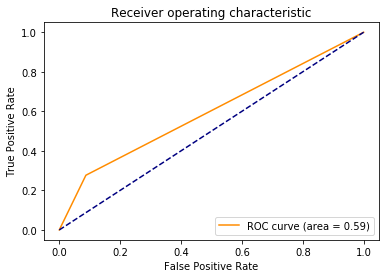

In [51]:
plt.plot(fpr, tpr, color='darkorange', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")

ROC curve can help you to choose a threshold that balances sensitivity and specificity in a way that makes sense for your particular context

# Q11. Calculate AUC(the percentage of the ROC plot that is underneath the curve) - optional

In [64]:
#Calculate AUC
auc = roc_auc_score(y_test, Rf_ypred)
print('AUC: %.3f' % auc)

AUC: 0.595


### Bootstrapping ( Bonus)
##### Given a dataset of size n, a bootstrap sample is created by sampling n instances uniformly from the data (with/without replacement)
##### Create a model with each bootstrap sample and validate it with the test set
##### Final result is calculated by averaging the accuracy of models

In [27]:
# Number of iterations for bootstrapping
bootstrap_iteration = 10
accuracy = []

In [66]:
from sklearn.utils import resample
from sklearn.metrics import accuracy_score

for i in range(bootstrap_iteration):
    X_, y_ = resample(X_train, y_train)
    Rf_model.fit(X_, y_)
    y_pred = Rf_model.predict(X_test)
    
    acc = accuracy_score(y_pred, y_test)
    accuracy.append(acc)

In [67]:
accuracy = np.array(accuracy)
print('Accuracy Score')
print('Avearge: ', accuracy.mean())
print('Standard deviation: ', accuracy.std())

Accuracy Score
Avearge:  0.7299999999999999
Standard deviation:  0.024267032964268395
